In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.14.1+cu126
True
NVIDIA GeForce RTX 3060 Ti


In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_data = datasets.MNIST(root = "data", train = True, download = True, transform = transform)
test_data = datasets.MNIST(root = "data", train = False, download = True, transform = transform)

print(len(train_data), len(test_data))

60000 10000


In [ ]:
"""
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
"""

In [3]:
print(train_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [23]:
print(type(train_data))

<class 'torchvision.datasets.mnist.MNIST'>


In [30]:
for item in dir(train_data):
    print(item)

__add__
__annotations__
__class__
__class_getitem__
__delattr__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__le__
__len__
__lt__
__module__
__ne__
__new__
__orig_bases__
__parameters__
__reduce__
__reduce_ex__
__repr__
__setattr__
__sizeof__
__static_attributes__
__str__
__subclasshook__
__weakref__
_check_exists
_check_legacy_exist
_format_transform_repr
_load_data
_load_legacy_data
_repr_indent
class_to_idx
classes
data
download
extra_repr
mirrors
processed_folder
raw_folder
resources
root
target_transform
targets
test_data
test_file
test_labels
train
train_data
train_labels
training_file
transform
transforms


In [26]:
help(train_data)

Help on MNIST in module torchvision.datasets.mnist object:

class MNIST(torchvision.datasets.vision.VisionDataset)
 |  MNIST(
 |      root: Union[str, pathlib._local.Path],
 |      train: bool = True,
 |      transform: Optional[Callable] = None,
 |      target_transform: Optional[Callable] = None,
 |      download: bool = False
 |  ) -> None
 |
 |  `MNIST <http://yann.lecun.com/exdb/mnist/>`_ Dataset.
 |
 |  Args:
 |      root (str or ``pathlib.Path``): Root directory of dataset where ``MNIST/raw/train-images-idx3-ubyte``
 |          and  ``MNIST/raw/t10k-images-idx3-ubyte`` exist.
 |      train (bool, optional): If True, creates dataset from ``train-images-idx3-ubyte``,
 |          otherwise from ``t10k-images-idx3-ubyte``.
 |      transform (callable, optional): A function/transform that  takes in a PIL image
 |          and returns a transformed version. E.g, ``transforms.RandomCrop``
 |      target_transform (callable, optional): A function/transform that takes in the
 |          

In [28]:
print(train_data.__dict__.keys())

dict_keys(['root', 'transform', 'target_transform', 'transforms', 'train', 'data', 'targets'])


In [4]:
print(train_data.data.shape)
print(train_data.data.dtype)
print(train_data.targets[:10])

torch.Size([60000, 28, 28])
torch.uint8
tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])


Data (Training):
We have 60000 images. It's 28 x 28 grid, a total of 784 pixels.
1 pixel is a number ranging from 0 to 255. 

In [31]:
print(train_data[0])

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0

In [5]:
image, label = train_data[0]
print(image.shape)
print(label)
print(image.min(), image.max())

torch.Size([1, 28, 28])
5
tensor(0.) tensor(1.)


In [6]:
torch.set_printoptions(linewidth=200)
print(train_data.data[0])

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170, 253, 253, 253, 253, 253, 2

In [7]:
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 64)

In [8]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels[:10])

torch.Size([64, 1, 28, 28])
tensor([1, 1, 1, 5, 1, 5, 3, 1, 1, 8])


iterator = iter(train_loader)

batch1 = next(iterator)
batch2 = next(iterator)
batch3 = next(iterator)

batch1 → first batch
batch2 → second batch
batch3 → third batch

torch.Size([64, 1, 28, 28])
64 batches, 1 brightness (black and white), Height, Width

RGB would be 64, 3, 28, 28

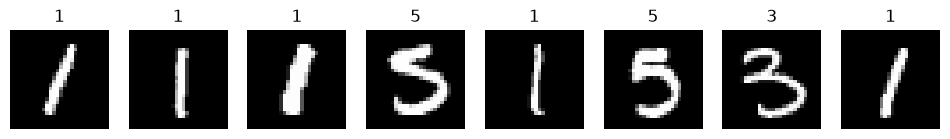

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 8, figsize = (12, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap = "gray")
    ax.set_title(labels[i].item())
    ax.axis("off")
plt.show()

In [10]:
import torch.nn as nn

class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.layers(x)
device = "cuda"
model = DigitNet().to(device)
print(model)

DigitNet(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [11]:
images = images.to(device)
output = model(images)
print(output.shape)
print(output[0])

torch.Size([64, 10])
tensor([ 0.0898, -0.0929, -0.0371, -0.0619, -0.0374, -0.0444,  0.0993, -0.1107, -0.0948, -0.0977], device='cuda:0', grad_fn=<SelectBackward0>)


In [12]:
from tqdm import tqdm

epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader, desc = f"Epoch {epoch + 1}"):
        images, labels = images.to(device), labels.to(device)

        output = model(images)
        loss = loss_fn(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} avg loss: {total_loss / len(train_loader)}")

Epoch 1: 100%|██████████| 938/938 [00:03<00:00, 264.47it/s]


Epoch 1 avg loss: 0.33393224282686645


Epoch 2: 100%|██████████| 938/938 [00:03<00:00, 266.19it/s]


Epoch 2 avg loss: 0.14850848800202868


Epoch 3: 100%|██████████| 938/938 [00:03<00:00, 240.93it/s]


Epoch 3 avg loss: 0.10380224049138997


Epoch 4: 100%|██████████| 938/938 [00:04<00:00, 232.17it/s]


Epoch 4 avg loss: 0.07825310485038374


Epoch 5: 100%|██████████| 938/938 [00:04<00:00, 228.67it/s]

Epoch 5 avg loss: 0.06122030829812195


In [16]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        preds = output.argmax(dim = 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
print(f"Test accuracy: {correct / total:.2%}")

Test accuracy: 97.67%


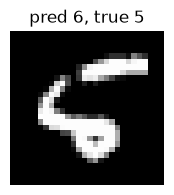

In [22]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    preds = model(images).argmax(dim = 1)
wrong = (preds != labels).nonzero().flatten()

fig, axes = plt.subplots(1, min(8, len(wrong)), figsize = (12,2), squeeze= False)
for ax, idx in zip(axes[0], wrong):
    ax.imshow(images[idx].cpu().squeeze(), cmap = "gray")
    ax.set_title(f"pred {preds[idx].item()}, true {labels[idx].item()}")
    ax.axis("off")
plt.show()